In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Random Data Creation

In [31]:
age = np.random.randint(18,65,200)
discount = np.random.randint(0,40,200)
z = (age * 0.1) + (discount * 0.2) - 6
probabilities = 1 / (1 + np.exp(-z))
bought = (probabilities > 0.5).astype(int)
df = pd.DataFrame({
    'Age': age,
    'Discount': discount,
    'Sales': bought
})
df.head()

,Age,Discount,Sales
0,47,4,0
1,56,24,1
2,55,26,1
3,37,0,0
4,30,2,0


In [32]:
X = df[['Age','Discount']]
y = df['Sales']

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [43]:
model = RandomForestClassifier(n_estimators=120,max_depth=5)
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",120
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [44]:
prediction = model.predict(X_test)
prediction

array([0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1])

In [45]:
accuracy = accuracy_score(y_test,prediction)
print(accuracy * 100)

95.0


In [46]:
cf = confusion_matrix(y_test,prediction)
cf

array([[12,  2],
       [ 0, 26]])

In [40]:
import seaborn as sns

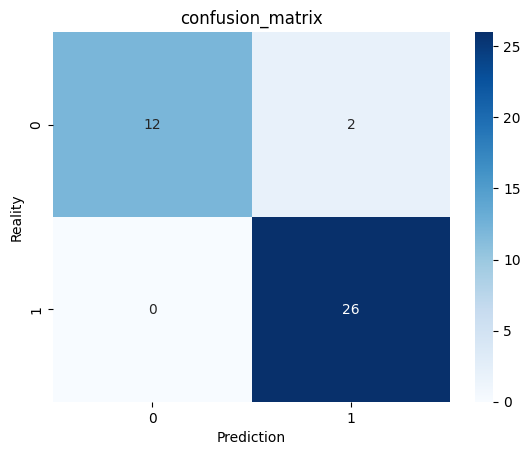

In [47]:
sns.heatmap(cf, annot=True, fmt='d', cmap='Blues')
plt.title("confusion_matrix")
plt.xlabel("Prediction")
plt.ylabel("Reality")
plt.show()

In [48]:
from sklearn.metrics import classification_report

In [50]:
report = classification_report(y_test, prediction)
print(report)


              precision    recall  f1-score   support

           0       1.00      0.86      0.92        14
           1       0.93      1.00      0.96        26

    accuracy                           0.95        40
   macro avg       0.96      0.93      0.94        40
weighted avg       0.95      0.95      0.95        40



In [64]:
uc_data = {
    'Age': [25, np.nan, 30, 22, np.nan, 40],
    'Gender': ['Male', 'Female', 'Male', 'Female', 'Male', 'Male'],
    'Product_Type': ['Aloo', 'Paneer', 'Aloo', 'Aloo', 'Paneer', np.nan],
    'Bill_Rs': [50, 80, 50, 50, 80, 100]
}

df = pd.DataFrame(uc_data)
print(df)

    Age  Gender Product_Type  Bill_Rs
0  25.0    Male         Aloo       50
1   NaN  Female       Paneer       80
2  30.0    Male         Aloo       50
3  22.0  Female         Aloo       50
4   NaN    Male       Paneer       80
5  40.0    Male          NaN      100


In [79]:
print(df)

     Age Gender  Bill_Rs Product_type
0  25.00      0       50            0
1  29.25      1       80            1
2  30.00      0       50            0
3  22.00      1       50            0
4  29.25      0       80            1
5  40.00      0      100            0


### Data cleaning.

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           6 non-null      float64
 1   Gender        6 non-null      object 
 2   Product_Type  6 non-null      str    
 3   Bill_Rs       6 non-null      int64  
 4   Product_type  6 non-null      object 
dtypes: float64(1), int64(1), object(2), str(1)
memory usage: 372.0+ bytes


In [66]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [69]:
df['Product_Type'] = df['Product_Type'].fillna(df['Product_Type'].mode()[0])

In [70]:
df['Gender'] = df['Gender'].replace(('Male','Female'),(0,1))


In [72]:
df['Product_type'] = df['Product_Type'].replace(('Aloo','Paneer'),(0,1))


In [ ]:
df = df.drop('Product_Type', axis=1)   # removing the extra column.

### Scaling -- important for fiting the number in a range so that model would not be confused dusring prediction.

In [80]:
from sklearn.preprocessing import MinMaxScaler

In [81]:
scaler = MinMaxScaler()
scaler_data = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaler_data, columns=df.columns)
df_scaled

,Age,Gender,Bill_Rs,Product_type
0,0.166667,0.0,0.0,0.0
1,0.402778,1.0,0.6,1.0
2,0.444444,0.0,0.0,0.0
3,0.000000,1.0,0.0,0.0
4,0.402778,0.0,0.6,1.0
5,1.000000,0.0,1.0,0.0
